In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rosemeenshaikh/top-10000-tmdbs-highest-rated-movies/top_rated_movies.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import xgboost as xgb

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/rosemeenshaikh/top-10000-tmdbs-highest-rated-movies/top_rated_movies.csv")
df.head()

,adult,id,original_language,original_title,overview,popularity,release_date,title,vote_average,vote_count
0,False,278,en,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,46.3708,1994-09-23,The Shawshank Redemption,8.718,30171
1,False,238,en,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",42.0006,1972-03-14,The Godfather,8.686,22787
2,False,240,en,The Godfather Part II,In the continuing saga of the Corleone crime f...,26.8671,1974-12-20,The Godfather Part II,8.571,13812
3,False,424,en,Schindler's List,The true story of how businessman Oskar Schind...,24.2944,1993-12-15,Schindler's List,8.567,17341
4,False,389,en,12 Angry Men,The defense and the prosecution have rested an...,19.4971,1957-04-10,12 Angry Men,8.559,9908


In [4]:
df = df.dropna()

# Convert date
df["release_date"] = pd.to_datetime(df["release_date"])
df["year"] = df["release_date"].dt.year

# Engagement score
df["engagement"] = df["vote_count"] * df["vote_average"]

# Popularity log
df["popularity_log"] = np.log1p(df["popularity"])

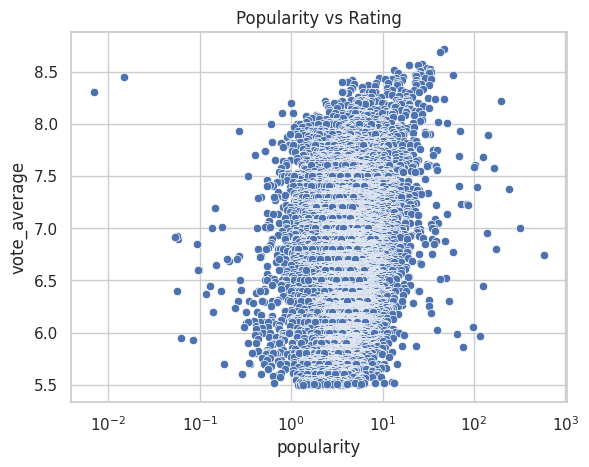

In [5]:
sns.scatterplot(x="popularity", y="vote_average", data=df)
plt.xscale("log")
plt.title("Popularity vs Rating")
plt.show()

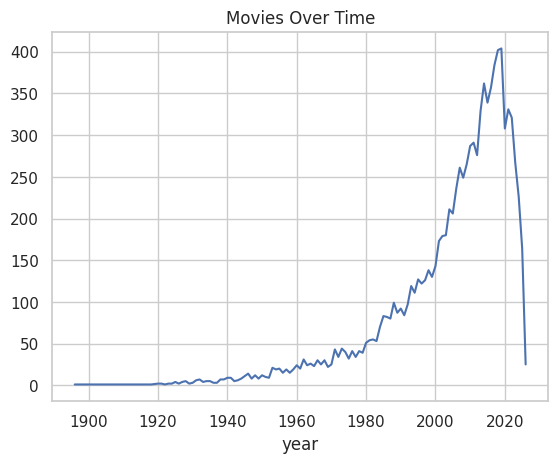

In [6]:
df["year"].value_counts().sort_index().plot()
plt.title("Movies Over Time")
plt.show()

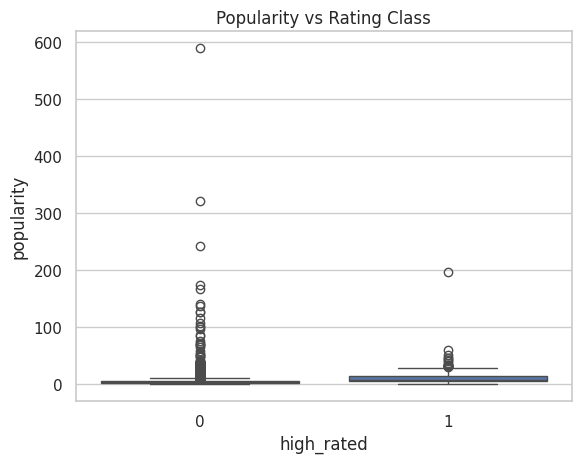

In [7]:
df["high_rated"] = (df["vote_average"] > 8).astype(int)

sns.boxplot(x="high_rated", y="popularity", data=df)
plt.title("Popularity vs Rating Class")
plt.show()

In [8]:
features = ["popularity", "vote_count", "year"]

X = df[features]
y = df["vote_average"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = xgb.XGBRegressor(n_estimators=300)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))

RMSE: 0.6431642415679358


In [9]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf.fit_transform(df["overview"])

In [10]:
cos_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(df.index, index=df["title"]).drop_duplicates()

def recommend(title, top_n=5):
    idx = indices[title]
    sim_scores = list(enumerate(cos_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    return df["title"].iloc[movie_indices]

recommend("The Shawshank Redemption")

4872          The Longest Yard
3148                  Brubaker
5719                   In Hell
6577    The 40 Year Old Virgin
724                 The Chorus
Name: title, dtype: object

In [11]:
cluster_features = df[["popularity", "vote_average", "vote_count"]]

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=4)
df["cluster"] = kmeans.fit_predict(scaled)

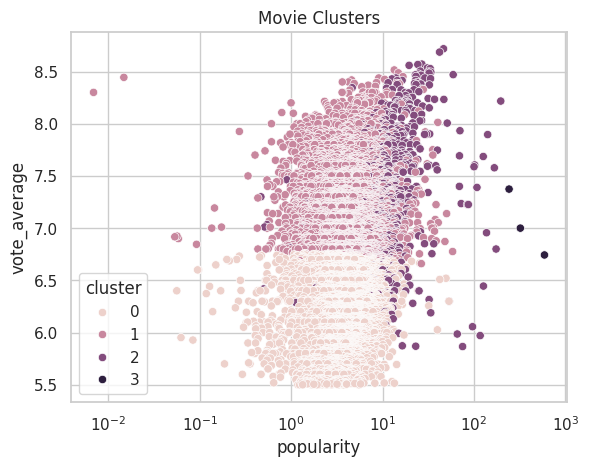

In [12]:
sns.scatterplot(
    x="popularity",
    y="vote_average",
    hue="cluster",
    data=df
)
plt.xscale("log")
plt.title("Movie Clusters")
plt.show()

In [13]:
top_movies = df[df["vote_average"] > 8.5]

print(top_movies[["title", "vote_average", "popularity"]].head())

                      title  vote_average  popularity
0  The Shawshank Redemption         8.718     46.3708
1             The Godfather         8.686     42.0006
2     The Godfather Part II         8.571     26.8671
3          Schindler's List         8.567     24.2944
4              12 Angry Men         8.559     19.4971


In [14]:
# Hidden gems
hidden_gems = df[(df["vote_average"] > 8) & (df["popularity"] < df["popularity"].median())]

hidden_gems[["title", "vote_average"]].head()

,title,vote_average
19,Grave of the Fireflies,8.444
43,Gabriel's Inferno: Part II,8.400
64,Dedicated to my ex,8.300
78,Out of the Clear Blue Sky,8.300
79,Hotarubi no Mori e,8.300


In [15]:
def simulate_popularity_effect(base_movie, new_popularity):
    temp = base_movie.copy()
    temp["popularity"] = new_popularity
    
    return model.predict(pd.DataFrame([temp]))[0]

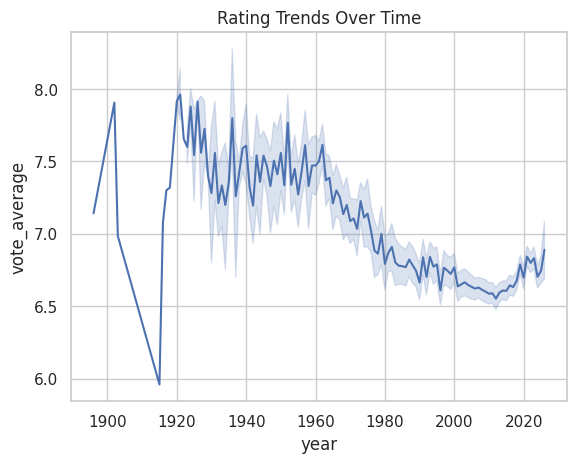

In [16]:
sns.lineplot(x="year", y="vote_average", data=df)
plt.title("Rating Trends Over Time")
plt.show()